# Deep Neural Network with Dropout using Keras

In [1]:
import tensorflow as tf

from tensorflow.keras import models
from tensorflow.keras import layers


import random
import numpy as np

In [2]:
random.seed(42)         # Initialize the random number generator.
np.random.seed(42)      # With the seed reset, the same set of numbers will appear every time.
#tf.set_random_seed(42)  # sets the graph-level random seed

## Dataset

In [3]:
# Use the MNIST dataset  of Keras.

mnist = tf.keras.datasets.mnist

(Xtrain, Ytrain) , (Xtest, Ytest) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [4]:
# Normalize the data
# 60000 input images are in the train set.
# 10000 input images are in the test set.

Xtrain = Xtrain.reshape((60000, 28*28))    # reshape the input set to size 28*28.
Xtrain = Xtrain.astype('float32')/255      # normalize to grayscale; set datatype as float32

Xtest = Xtest.reshape((10000, 28*28))      # reshape the input set to size 28*28.
Xtest = Xtest.astype('float32')/255        # normalize to grayscale; set datatype as float32

Ytrain = tf.keras.utils.to_categorical(Ytrain)
Ytest = tf.keras.utils.to_categorical(Ytest)

## DNN Model

Using Keras, create the DNN or Sequential Model

In [5]:
# Create a model object

dnnModel = models.Sequential()

Add dense layers, specifying the number of units in each layer and the activation function used in the layer.

In [6]:
# Layer 1 = input layer
# specify the input size for in the first layer.

dnnModel.add(layers.Dense(50, activation='relu', input_shape= (28*28,)))

# Layer 2 = hidden layer
dnnModel.add(layers.Dense(60, activation='relu'))

# Add dropout of 50% to layer 2
dnnModel.add(layers.Dropout(0.5))

# Layer 3 = hidden layer
dnnModel.add(layers.Dense(30, activation='relu'))

# Add dropout of 50% to layer 3
#dnnModel.add(layers.Dropout(0.5))
#
# Layer 4 = output layer
dnnModel.add(layers.Dense(10, activation='softmax'))

dnnModel.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                39250     
                                                                 
 dense_1 (Dense)             (None, 60)                3060      
                                                                 
 dropout (Dropout)           (None, 60)                0         
                                                                 
 dense_2 (Dense)             (None, 30)                1830      
                                                                 
 dense_3 (Dense)             (None, 10)                310       
                                                                 
Total params: 44450 (173.63 KB)
Trainable params: 44450 (173.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Regularization and Optimizations of DNN

In [7]:
# Configure  the model for training, by using appropriate optimizers and regularizations
# Available optimizer: adam, rmsprop, adagrad, sgd
# loss:  objective that the model will try to minimize.
# Available loss: categorical_crossentropy, binary_crossentropy, mean_squared_error
# metrics: List of metrics to be evaluated by the model during training and testing.

dnnModel.compile( optimizer = 'adam', loss = 'categorical_crossentropy', metrics=['accuracy'] )

## Train the Model

In [8]:
# train the model

h = dnnModel.fit( Xtrain, Ytrain, validation_split=0.2, epochs=25, batch_size=64)

Epoch 1/25
750/750 [==============================] - 9s 4ms/step - loss: 0.6609 - accuracy: 0.7939 - val_loss: 0.2227 - val_accuracy: 0.9344
Epoch 2/25
750/750 [==============================] - 4s 5ms/step - loss: 0.2783 - accuracy: 0.9208 - val_loss: 0.1614 - val_accuracy: 0.9509
Epoch 3/25
750/750 [==============================] - 3s 4ms/step - loss: 0.2108 - accuracy: 0.9410 - val_loss: 0.1336 - val_accuracy: 0.9598
Epoch 4/25
750/750 [==============================] - 3s 4ms/step - loss: 0.1736 - accuracy: 0.9507 - val_loss: 0.1268 - val_accuracy: 0.9628
Epoch 5/25
750/750 [==============================] - 3s 4ms/step - loss: 0.1526 - accuracy: 0.9563 - val_loss: 0.1185 - val_accuracy: 0.9657
Epoch 6/25
750/750 [==============================] - 4s 5ms/step - loss: 0.1311 - accuracy: 0.9625 - val_loss: 0.1207 - val_accuracy: 0.9657
Epoch 7/25
750/750 [==============================] - 3s 4ms/step - loss: 0.1203 - accuracy: 0.9646 - val_loss: 0.1173 - val_accuracy: 0.9674
Epoch 

In [10]:
print('Final training loss \t', h.history['loss'][-1])
print('Final training accuracy ', h.history['accuracy'][-1])

Final training loss 	 0.047204528003931046
Final training accuracy  0.9851874709129333


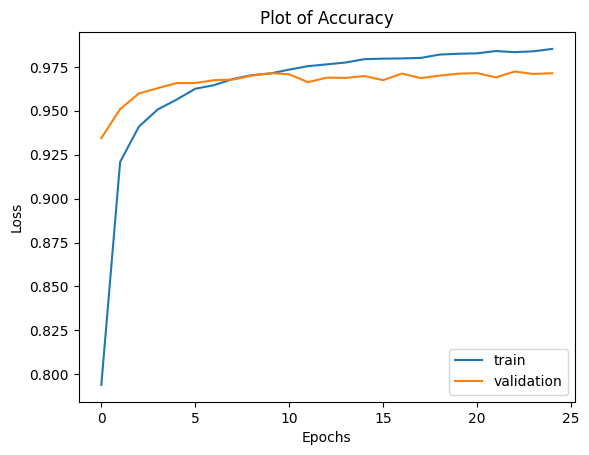

In [13]:
# plot the training  accuracy
import matplotlib.pyplot as plt

plt.plot(h.history['accuracy'], label='train')
plt.plot(h.history['val_accuracy'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Plot of Accuracy')
plt.legend()
plt.show()

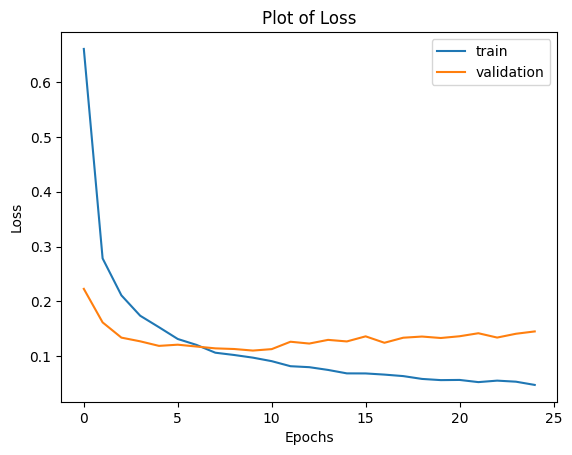

In [14]:
# plot the traininig loss


plt.plot(h.history['loss'], label='train')
plt.plot(h.history['val_loss'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Plot of Loss')
plt.legend()
plt.show()

## Testing the Model

In [15]:
# testing the model

testLoss, testAccuracy = dnnModel.evaluate( Xtest, Ytest)

313/313 [==============================] - 1s 4ms/step - loss: 0.1266 - accuracy: 0.9737


In [16]:
print('Testing loss \t', testLoss)
print('Testing accuracy ', testAccuracy)

Testing loss 	 0.12664523720741272
Testing accuracy  0.9736999869346619


Modify the code to get a better testing accuracy.
- Change the number of hidden units
- Increase the number of hidden layers
- Use a different optimizer